### Preamble

> ⚠️ **Warning:** This notebook file is paired to a .py file with the same name, such that we can cleanly import the functionality from other notebooks. This is done using the facilities of the jupytext package. The cells in this notebook that are only meant as "demonstration" are marked with the cell tag "active-ipynb", which causes the jupytext synchronization command to ignore these when syncing to the .py file. This is our current way of doing "literate programming" with jupyter notebooks.

In [178]:
import numpy as np
import pandas as pd
import networkx as nx
import os
import matplotlib.pyplot as plt

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/jeroen/repos/traffic-scheduling/network


# Getting started

## Network instance data class

In [180]:
from dataclasses import dataclass

@dataclass
class NetworkInstance:
    G: nx.DiGraph
    routes: list[np.ndarray] | None = None

    arrivals: list[np.ndarray] | None = None

    rho:   float = 1.2   # following time
    sigma: float = 1.7   # time between conflicting vehicles
    vmax:  float = 1     # maximum speed

    @property
    def switch(self): return self.sigma - self.rho

    @property
    def R(self): return len(self.arrivals)
    @property
    def n(self): return [len(self.arrivals[r]) for r in range(self.R)]
    @property
    def N(self): return sum(self.n)

    @property
    def vehicle_indices(self):
        """Get list of vehicle indices {(r, k)} from instance specification,
        assuming consecutive numbering from 0 (so without gaps)."""
        R = range(self.R); n = [range(self.n[r]) for r in R]
        # use 'sorted' to guarantee lexicographical order
        return sorted([(r, k) for r in R for k in n[r]])
    

Connect some drawing function to this class, for convenient access.

In [ ]:
from traffic_scheduling.network.drawing import draw_graph, draw_road

NetworkInstance.draw_graph = lambda self: draw_graph(self.G)
NetworkInstance.draw_road = lambda self, **kwargs: draw_road(self.G, **kwargs)

## Optimal schedules with integer programming

### Schedule data class

Plus schedule visualization, as Gantt chart.

In [460]:
from typing import Optional

@dataclass
class NetworkMILPSchedule:
    instance: NetworkInstance
    y: list[np.ndarray]
    obj: float
    done: bool
    gap: float
    time: float
    progress: Optional[pd.DataFrame] = None

    @property
    def makespan(self):
        return max(self.y.values()) + self.instance.rho

Keep the schedule plot function local to this class, for convenience.

In [ ]:
from traffic_scheduling.network.drawing import plot_schedule
NetworkMILPSchedule.plot_schedule = lambda self: plot_schedule(self)

### Mixed-integer linear programming

> Note: this implementation uses Pyomo with SCIP. The previous `recordprogress` option has been removed because tracking MIP progress over time with Pyomo+SCIP is more involved compared to the previous implementation with Gurobi, and would require parsing solver logs afterward. Hence, the benchmark `notebooks/network/milp-benchmark-progress.ipynb` does not work anymore with the current implementation.

In [211]:
from pyomo.environ import *
from pyomo.core import ConcreteModel, Var, ConstraintList, Objective, NonNegativeReals, Binary, minimize, value
from pyomo.opt import SolverFactory, TerminationCondition
from itertools import product, combinations
from traffic_scheduling.network.util import dist

def solve(instance, gap=0.0, timelimit=0, consolelog=False, logfile=None):
    """Solve a network scheduling problem as a MILP."""
    routes = instance.routes
    arrivals = instance.arrivals

    rho = instance.rho
    sigma = instance.sigma

    R = instance.R # number of routes
    n = instance.n # number of arrivals per route

    # big-M
    M = 1000

    g = ConcreteModel()
    g.yvars = VarList = []  # placeholder to keep style close; actual vars stored in `y` dict
    g.conjunctions = ConstraintList()
    g.disjunctions = ConstraintList()
    g.distances = ConstraintList()
    g.buffers = ConstraintList()

    y = {}
    objective_terms = []

    # release time parameters and crossing time variables
    for l in range(R):
        for k in range(n[l]):
            for r in range(len(routes[l]) - 1): # skip the last node in each route, which is the exit point
                v = routes[l][r]
                if r == 0: # entrypoint
                    y[l, k, v] = arrivals[l][k]
                else: # intersections
                    y[l, k, v] = Var(domain=NonNegativeReals)
                    setattr(g, f"y_{l}_{k}_{r}", y[l, k, v])
                    objective_terms.append(y[l, k, v])

    # conjunctions...
    for l in range(R):
        for v in routes[l][1:-1]: # ...on all except the first and last node on each route
            for k in range(n[l] - 1):
                g.conjunctions.add(y[l, k, v] + rho <= y[l, k + 1, v])

    # disjunctions at route intersections
    for l1, l2 in combinations(range(R), 2):
        # intersections of routes is set of "merge points"
        for v in set(routes[l1]) & set(routes[l2]):
            for k1, k2 in product(range(n[l1]), range(n[l2])):
                oc = Var(domain=Binary)
                setattr(g, f"o_{l1}_{k1}_{l2}_{k2}", oc)

                g.disjunctions.add(y[l1, k1, v] + sigma <= y[l2, k2, v] + oc * M)
                g.disjunctions.add(y[l2, k2, v] + sigma <= y[l1, k1, v] + (1 - oc) * M)

    # distances
    for l in range(R):
        for k in range(n[l]):
            # skip the distance constraint to the exit point, we compute the entry time
            # at the exit point after solving
            for r in range(len(routes[l]) - 2):
                v = routes[l][r]
                w = routes[l][r + 1]
                g.distances.add(y[l, k, w] >= y[l, k, v] + dist(instance.G, v, w) / instance.vmax)

    # buffers
    for l in range(R):
        for r in range(len(routes[l]) - 1):
            v = routes[l][r]
            w = routes[l][r + 1]
            capacity = instance.G.edges[v, w]['capacity']
            if capacity == -1:
                continue
            for k in range(n[l] - capacity):
                rho_hat = capacity * rho - dist(instance.G, v, w) / instance.vmax
                g.buffers.add(y[l, k, w] + rho_hat <= y[l, k + capacity, v])

    g.obj = Objective(expr=sum(objective_terms), sense=minimize)

    solver = SolverFactory("scip")
    if not solver.available(False):
        raise RuntimeError(
            "SCIP executable not found. Install SCIP and ensure `scip` is on PATH to use this solver."
        )
    if gap > 0:
        solver.options["limits/gap"] = gap
    if timelimit > 0:
        solver.options["limits/time"] = timelimit
    if not consolelog:
        solver.options["display/verblevel"] = 0

    solve_kwargs = {"tee": consolelog}
    if logfile is not None:
        os.makedirs(os.path.dirname(os.path.abspath(logfile)), exist_ok=True)
        solve_kwargs["logfile"] = logfile

    results = solver.solve(g, **solve_kwargs)

    # compute the arrival time at the exit point for each vehicle, which is computed from the entry time at the last
    # intersection and the travel time
    for l in range(R):
        for k in range(n[l]):
            v = routes[l][-2]
            w = routes[l][-1]
            y[l, k, w] = value(y[l, k, v]) + dist(instance.G, v, w) / instance.vmax

    res = {}
    res['y'] = { k : (value(v) if hasattr(v, 'is_expression_type') or hasattr(v, 'is_variable_type') else v) for k, v in y.items() }
    res['obj'] = value(g.obj)
    res['done'] = int(results.solver.termination_condition == TerminationCondition.optimal)

    upper = getattr(results.problem, "upper_bound", None)
    lower = getattr(results.problem, "lower_bound", None)
    if upper is not None and lower is not None and np.isfinite(upper) and np.isfinite(lower):
        res['gap'] = abs(upper - lower) / (abs(upper) + 1e-10)
    elif res['done']:
        res['gap'] = 0.0
    else:
        res['gap'] = np.nan

    res['time'] = getattr(results.solver, "time", 0.0) or 0.0

    return NetworkMILPSchedule(instance=instance, **res)

Keep this method at the instance class, for convenience.

In [184]:
def solve_myself(self, **kwargs): self.opt = solve(self, **kwargs); return self.opt
NetworkInstance.solve = solve_myself

## Instance generation

### Network generation

In [191]:
from collections.abc import Iterable

def generate_grid_network(m=None, n=None, xdist=[10, 10], ydist=[10]):
    """Generate a grid network.

    Either specify:
    
    - number of columns (m) and rows (n) of intersection,
    with fixed horizontal (xdist) and vertical (ydist) spacing;

    - two lists of horizontal (xdist) and vertical (ydist) distances between
    consecutive intersections, such that there are `m = len(xdist) - 1` columns
    and `n = len(ydist) - 1` rows of intersections.

    Returns (G, routes), where G is a networkx graph and each route is a list of
    nodes. At the edges of the network, we also connect each intersection to an
    inbound/outbound node. Therefore, the total number of nodes is n*m +
    2*(n+m). Pure intersections nodes are stored in `network.intersections`. We
    generate all straight routes from west to east and from south to north."""

    G = nx.DiGraph()
    G.intersections = []

    assert m is not None or isinstance(xdist, Iterable), "Either specify m or provide xdist list."
    assert n is not None or isinstance(ydist, Iterable), "Either specify n or provide ydist list."
    if not isinstance(xdist, Iterable): xdist = [xdist] * (m+1)
    if not isinstance(ydist, Iterable): ydist = [ydist] * (n+1)
    if m is None: m = len(xdist) - 1
    if n is None: n = len(ydist) - 1

    def node(x, y):
        if (i == 0 or i == m+1) and (j == 0 or j == n+1): return # skip the corners
        G.add_node((i,j), pos=(x, y))
        # collect pure intersections (not inbound/outbound)
        if not (i == 0 or i == m+1) and not (j == 0 or j == n+1):
            G.intersections.append((i,j))

    # 1. Generate nodes
    # The node in the i'th row and j'th column is identified as (i,j).
    x = 0
    for i in range(m + 2):
        y = 0
        for j in range(n + 2):
            node(x, y)
            if j <= n: y += ydist[j]
        if i <= m: x += xdist[i]

    # 2. Add edges
    for i in range(m + 1):
        for j in range(n + 1):
            if i == 0 and j == 0:
                continue # skip first corner

            # only both direction in the "interior"
            # negative capacity = unlimited
            if j != 0: G.add_edge((i,j), (i+1,j), capacity=-1, dist=xdist[i])
            if i != 0: G.add_edge((i,j), (i,j+1), capacity=-1, dist=ydist[j])

    # 3. Generate straight routes
    routes = [[] for _ in range(n+m)]
    for i in range(m + 2):
        for j in range(n + 2):
            if i != 0 and i != m+1: routes[i-1].append((i,j))   # west-east
            if j != 0 and j != n+1: routes[m+j-1].append((i,j)) # south-north

    return G, routes

### Instance generation

Reuse the route arrival generation function from the single intersection.

In [ ]:
from traffic_scheduling.single.basics import uniform, clipped, bimodal_exponential

In [ ]:
from collections.abc import Iterable
from traffic_scheduling.single.basics import arrivals_from_gaps

def generate_instance(F, n, rho=1.2, sigma=1.7, net_m=3, net_n=2, distance=10):
    G, routes = generate_grid_network(net_m, net_n, distance, distance)
    R = len(routes)

    arrivals = []
    for r in range(R):
        # make explicit singletons
        if not callable(F): f = F[r]
        else: f = F
        if isinstance(n, Iterable): n1 = n[r]
        else: n1 = n

        # create random interarrival times ("gaps") and cumulate them to obtain
        # earliest arrival times
        arrivals.append(arrivals_from_gaps(f(n1), rho))

    instance = NetworkInstance(G, routes, arrivals)
    return instance


def generate_simple_instance(n=[10, 10, 10, 10], net_m=2, net_n=2):
    return generate_instance(clipped(uniform()), n, net_m=net_m, net_n=net_n)

## Testing

### Solving

In [487]:
F = clipped(uniform(1, 3), min=0.1)
instance = generate_instance(F, n=[3,3], net_m=1, net_n=1)
instance.solve(timelimit=10, recordprogress=True);
# instance.draw_graph();
# instance.draw_road();

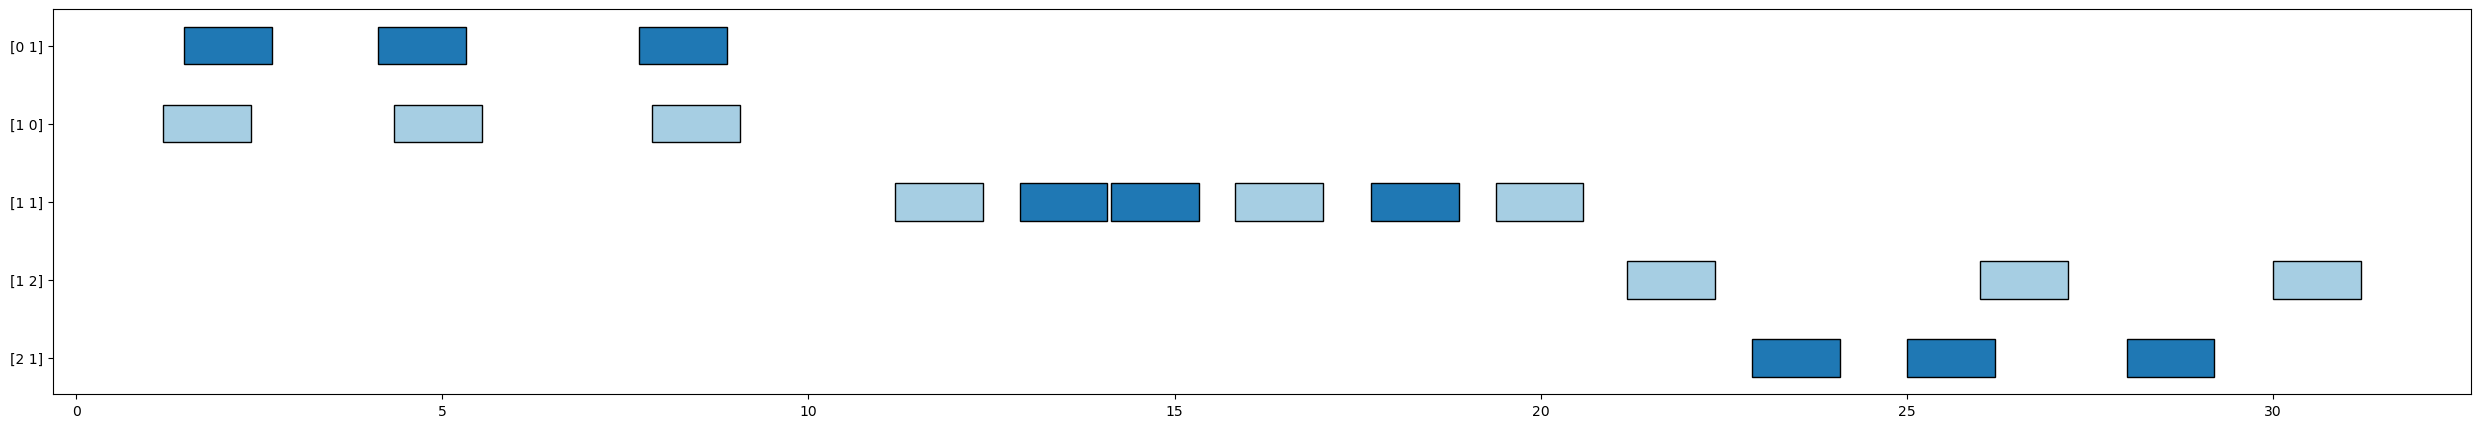

In [488]:
instance.opt.plot_schedule()

### Trajectories from scheduled crossing times

In [ ]:
from traffic_scheduling.motion import generate_trajectories
params = dict(vmax=1, umax=1, l=1.19, dt=0.25)
trajectories = generate_trajectories(instance.G, instance.routes, instance.arrivals, instance.opt.y, 1.2, params)

SCIP 9.0.1: WARNING: No dual information available when presolving was performed.
SCIP 9.0.1: optimal solution; objective 784.1250002
873 simplex iterations
SCIP 9.0.1: WARNING: No dual information available when presolving was performed.
SCIP 9.0.1: optimal solution; objective 857.3500007
1920 simplex iterations
SCIP 9.0.1: WARNING: No dual information available when presolving was performed.
SCIP 9.0.1: optimal solution; objective 895.2750006
2441 simplex iterations
SCIP 9.0.1: WARNING: No dual information available when presolving was performed.
SCIP 9.0.1: optimal solution; objective 838.2000002
1920 simplex iterations
SCIP 9.0.1: WARNING: No dual information available when presolving was performed.
SCIP 9.0.1: optimal solution; objective 857.7425008
1601 simplex iterations
SCIP 9.0.1: WARNING: No dual information available when presolving was performed.
SCIP 9.0.1: optimal solution; objective 822.2375007
920 simplex iterations


In [490]:
def plot_trajectories(trajectories, dt):
    for r in range(len(trajectories)):
        for k in range(len(trajectories[r])):
            t0 = trajectories[r][k][0]
            ts = len(trajectories[r][k][1])
            t = [t0 + i*dt for i in range(len(trajectories[r][k][1]))]
            plt.plot(t, trajectories[r][k][1], 'k')
        plt.show()

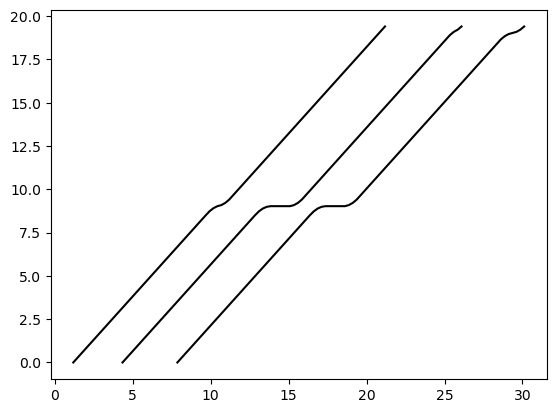

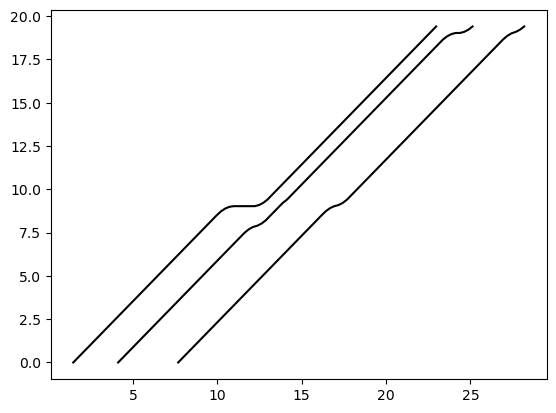

In [491]:
plot_trajectories(trajectories, 0.25)